In [1]:
import hats_import
import hats
import pandas as pd
import nested_pandas as npd

In [2]:
(hats_import.__version__, hats.__version__)


('0.10.0', '0.10.0')

## Photo-Z import for DP2

## Creating the import file list

In [3]:
#paths
pz = "/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data"
band4 = "/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band" # dir of .pq
band6 = "/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/6band" # dir of .pq
tract_csv = "/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/tract_lists.csv"

In [4]:
# tract list details which band set is recommended for each tract.
tract_df = pd.read_csv(tract_csv)
tract_df

,tract,in_4band,in_6band,recommended_band
0,2078,True,False,4
1,2079,True,False,4
...,...,...,...,...
1389,11403,True,False,4
1390,11640,True,False,4


In [5]:
# create the filenames for each tract based on the recommended band
fnames = tract_df.apply(lambda x: 
                f"{pz}/{x.recommended_band}band/pz_point_estimates_tract_{x.tract}.parquet",
                axis=1)
tract_with_fnames = tract_df.join(fnames.rename("filenames"))
tract_with_fnames

,tract,in_4band,in_6band,recommended_band,filenames
0,2078,True,False,4,/sdf/home/z/ztq1996/u/photoz/dp2/production_ls...
1,2079,True,False,4,/sdf/home/z/ztq1996/u/photoz/dp2/production_ls...
...,...,...,...,...,...
1389,11403,True,False,4,/sdf/home/z/ztq1996/u/photoz/dp2/production_ls...
1390,11640,True,False,4,/sdf/home/z/ztq1996/u/photoz/dp2/production_ls...


In [6]:
# verify we can read a file
npd.read_parquet(tract_with_fnames.loc[52]["filenames"])

,objectId,ra,dec,bpz_zmode,bpz_zmean,bpz_zmedian,bpz_zbest,bpz_z_err68_low,bpz_z_err68_high,bpz_z_err95_low,bpz_z_err95_high,dnf_zmode,dnf_zmean,dnf_zmedian,dnf_zbest,dnf_z_err68_low,dnf_z_err68_high,dnf_z_err95_low,dnf_z_err95_high,fzboost_zmode,fzboost_zmean,fzboost_zmedian,fzboost_zbest,fzboost_z_err68_low,fzboost_z_err68_high,fzboost_z_err95_low,fzboost_z_err95_high,gpz_zmode,gpz_zmean,gpz_zmedian,gpz_zbest,gpz_z_err68_low,gpz_z_err68_high,gpz_z_err95_low,gpz_z_err95_high,knn_zmode,knn_zmean,knn_zmedian,knn_zbest,knn_z_err68_low,knn_z_err68_high,knn_z_err95_low,knn_z_err95_high,tpz_zmode,tpz_zmean,tpz_zmedian,tpz_zbest,tpz_z_err68_low,tpz_z_err68_high,tpz_z_err95_low,tpz_z_err95_high
0,743562605347471948,224.691411,-41.651887,0.0,<NA>,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,1.15,1.44096,1.411974,1.712121,0.481356,2.44258,0.079121,2.897539,0.98,1.018716,0.998196,1.002796,0.94655,1.079593,0.902112,1.264304,0.0,-0.043154,-0.043154,0.519696,-1.072711,1.02986,-2.072295,1.985987,0.03,0.324708,0.303764,0.307002,0.034611,0.392688,0.00124,0.981569,1.32,1.680559,1.330812,1.124797,0.94044,2.718927,0.68475,4.460979
1,743562605347471955,224.684209,-41.650907,0.0,<NA>,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,0.0,1.346448,1.270892,1.538736,0.38127,2.393586,0.058435,2.890861,0.84,1.31035,0.852792,0.844349,0.771357,1.345853,0.260158,5.262835,0.0,-0.33536,-0.33536,0.402011,-1.369319,0.742243,-2.373177,1.702458,0.33,0.481887,0.386713,0.354126,0.184889,0.928568,0.062444,0.992031,0.92,1.089998,1.05543,1.025172,0.883823,1.338131,0.747232,1.599829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708100,743569408575687888,222.898492,-40.202447,1.67,1.753943,1.781715,1.809843,1.126674,2.452934,0.357498,2.801871,0.0,1.490253,1.478103,1.975361,0.468456,2.5386,0.072923,2.922804,0.26,1.943351,1.677338,1.727103,0.267965,3.457477,0.201396,5.037338,3.0,5.045389,5.045389,4.861118,4.008733,6.125801,3.002258,7.08852,0.11,0.755152,0.652867,0.136226,0.115253,1.430689,0.060876,1.624671,1.03,1.778544,1.171825,0.981733,0.711662,3.238745,0.235313,4.612099
708101,743569408575687889,222.899222,-40.202031,2.19,1.82422,1.981794,2.078111,1.200646,2.33059,0.307693,2.664026,1.52,1.505444,1.500961,1.9656,0.492428,2.53888,0.078175,2.922026,1.18,1.782301,1.313686,1.200697,1.068926,2.329249,0.624403,5.348237,1.58,1.576381,1.576381,1.592259,0.993723,2.183634,0.428027,2.724735,1.97,1.393726,1.345275,1.237718,1.048268,1.971519,0.307505,2.209767,1.68,1.518695,1.501889,1.448984,1.090379,1.998718,0.644752,2.359171


In [7]:
# verify recommendation consistency
print(len(tract_with_fnames.query("filenames.str.contains('6band')")) == len(tract_with_fnames.query("recommended_band == 6")))
print(len(tract_with_fnames.query("filenames.str.contains('4band')")) == len(tract_with_fnames.query("recommended_band == 4")))

True
True


In [8]:
# Collect the file list
file_list = tract_with_fnames.filenames.tolist()
file_list[0:5]

['/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band/pz_point_estimates_tract_2078.parquet',
 '/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band/pz_point_estimates_tract_2079.parquet',
 '/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band/pz_point_estimates_tract_2080.parquet',
 '/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band/pz_point_estimates_tract_2233.parquet',
 '/sdf/home/z/ztq1996/u/photoz/dp2/production_lsdb/data/4band/pz_point_estimates_tract_2234.parquet']

## Importing

In [ ]:
from hats_import.catalog.arguments import ImportArguments
from dask.distributed import Client
from hats_import.pipeline import pipeline_with_client

args = ImportArguments(
    sort_columns="objectId",
    ra_column="ra",
    dec_column="dec",
    input_file_list=file_list,
    file_reader="parquet",
    output_artifact_name="photo_z_point_estimates",
    output_path="/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2_pz",
)

with Client(n_workers=8) as client:
    print(client)
    pipeline_with_client(args, client)

<Client: 'tcp://127.0.0.1:14825' processes=8 threads=120, memory=503.37 GiB>


Catalog: Planning  :   0%|          | 0/4 [00:00<?, ?it/s]

Catalog: Mapping   :   0%|          | 0/1391 [00:00<?, ?it/s]

Catalog: Binning   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Splitting :   0%|          | 0/1391 [00:00<?, ?it/s]

Catalog: Reducing  :   0%|          | 0/1368 [00:00<?, ?it/s]

Catalog: Finishing :   0%|          | 0/6 [00:00<?, ?it/s]

## Verification

In [12]:
import lsdb

pz = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2_pz/photo_z_point_estimates")
pz

,objectId,ra,dec,bpz_zmode,bpz_zmean,bpz_zmedian,bpz_zbest,bpz_z_err68_low,bpz_z_err68_high,bpz_z_err95_low,bpz_z_err95_high,dnf_zmode,dnf_zmean,dnf_zmedian,dnf_zbest,dnf_z_err68_low,dnf_z_err68_high,dnf_z_err95_low,dnf_z_err95_high,fzboost_zmode,fzboost_zmean,fzboost_zmedian,fzboost_zbest,fzboost_z_err68_low,fzboost_z_err68_high,fzboost_z_err95_low,fzboost_z_err95_high,gpz_zmode,gpz_zmean,gpz_zmedian,gpz_zbest,gpz_z_err68_low,gpz_z_err68_high,gpz_z_err95_low,gpz_z_err95_high,knn_zmode,knn_zmean,knn_zmedian,knn_zbest,knn_z_err68_low,knn_z_err68_high,knn_z_err95_low,knn_z_err95_high,tpz_zmode,tpz_zmean,tpz_zmedian,tpz_zbest,tpz_z_err68_low,tpz_z_err68_high,tpz_z_err95_low,tpz_z_err95_high
npartitions=1368,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 3, Pixel: 265",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 4, Pixel: 1064",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49136",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [13]:
len(pz)

656768368

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - photo_z_point_estimates'}>)

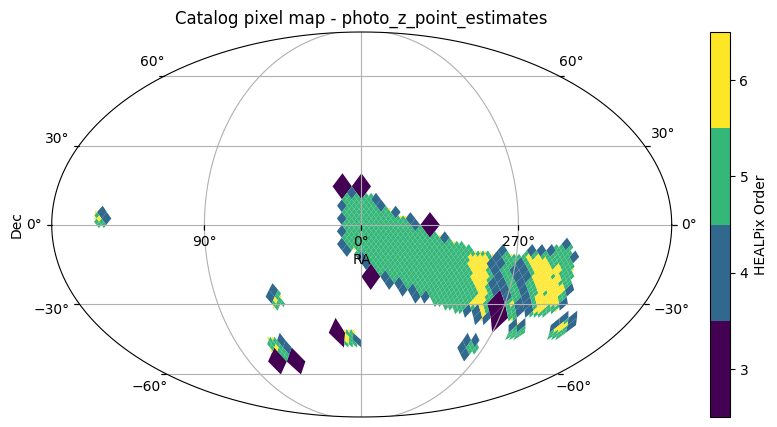

In [14]:
pz.plot_pixels()